In [75]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# **Data Loading**

In [76]:
def load_wesad_subject(file_path):
    with open(file_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    return data

In [77]:
from scipy.signal import resample

def resample_signal(signal, target_len):
    return resample(signal, target_len)

# **Data Preparation**

In [78]:
def extract_signals_labels(data, 
                           chest_sensors=['ACC', 'ECG', 'Resp'], 
                           wrist_sensors=['ACC', 'EDA', 'TEMP', 'BVP'],
                           window_size=128,
                           overlap=0.5,
                           normalize=True,
                           return_modalities=False):
    """
    Extracts and windows multimodal WESAD data.

    Parameters:
    - data: A dictionary containing 'signal' and 'label'
    - chest_sensors: List of chest sensors to include
    - wrist_sensors: List of wrist sensors to include
    - window_size: Number of timesteps per segment
    - overlap: Fraction overlap between windows (0.0 to 0.9)
    - normalize: Whether to apply standard normalization
    - return_modalities: Whether to return chest/wrist separately

    Returns:
    - X: Segmented sensor data [num_windows, window_size, features]
    - y: Corresponding labels
    - Optional: chest_windows, wrist_windows
    """
    chest = data['signal']['chest']
    wrist = data['signal']['wrist']
    labels = data['label']

    # Determine the min usable length (64 Hz equivalent)
    min_len = min([
        len(wrist[s]) for s in wrist_sensors if s in wrist
    ] + [
        int(len(chest[s]) * (64 / 700)) for s in chest_sensors if s in chest
    ] + [len(labels)])

    # Resample chest to 64Hz
    chest_data = np.concatenate([
        resample_signal(chest[s][:int(min_len * 700 / 64)], min_len).reshape(min_len, -1)
        for s in chest_sensors if s in chest
    ], axis=1)

    wrist_data = np.concatenate([
        wrist[s][:min_len] for s in wrist_sensors if s in wrist
    ], axis=1)

    if normalize:
        chest_data = (chest_data - chest_data.mean(axis=0)) / chest_data.std(axis=0)
        wrist_data = (wrist_data - wrist_data.mean(axis=0)) / wrist_data.std(axis=0)

    # Combine all modalities
    all_data = np.concatenate([chest_data, wrist_data], axis=1)
    labels = labels[:min_len]

    # Calculate step size based on overlap
    step_size = max(1, int(window_size * (1 - overlap)))

    # Sliding windows
    X, y = [], []
    chest_windows, wrist_windows = [], []
    
    for start in range(0, len(all_data) - window_size + 1, step_size):
        end = start + window_size
        window = all_data[start:end]
        label_window = labels[start:end]
        majority_label = np.bincount(label_window).argmax()
        
        X.append(window)
        y.append(majority_label)
        
        if return_modalities:
            chest_windows.append(chest_data[start:end])
            wrist_windows.append(wrist_data[start:end])

    print(f"Generated {len(X)} windows (window size: {window_size}, step: {step_size})")

    if return_modalities:
        return np.array(X), np.array(y), np.array(chest_windows), np.array(wrist_windows)
    return np.array(X), np.array(y)



In [79]:
def load_all_wesad_data(base_path='WESAD/', 
                        subject_ids=None,  # skip S1 (incomplete)
                        chest_sensors=['ACC', 'ECG', 'Resp'], 
                        wrist_sensors=['ACC', 'EDA', 'TEMP', 'BVP'],
                        window_size=128,
                        overlap=0.5,
                        normalize=True,
                        return_modalities=False):
    if subject_ids is None:
        subject_ids = [i for i in range(2, 18) if i != 12]

    X_all, y_all = [], []
    chest_all, wrist_all = [], []

    for subject_id in subject_ids:
        file_path = os.path.join(base_path, f'S{subject_id}', f'S{subject_id}.pkl')
        print(f"Loading subject S{subject_id}")
        data = load_wesad_subject(file_path)
        
        results = extract_signals_labels(
            data,
            chest_sensors=chest_sensors,
            wrist_sensors=wrist_sensors,
            window_size=window_size,
            overlap=overlap,
            normalize=normalize,
            return_modalities=return_modalities
        )

        if return_modalities:
            X, y, chest_data, wrist_data = results
            chest_all.append(chest_data)
            wrist_all.append(wrist_data)
        else:
            X, y = results
        
        X_all.append(X)
        y_all.append(y)

    X_all = np.concatenate(X_all)
    y_all = np.concatenate(y_all)

    if return_modalities:
        return X_all, y_all, np.concatenate(chest_all), np.concatenate(wrist_all)
    
    return X_all, y_all


In [80]:
path='WESAD/'
X, y = load_all_wesad_data(window_size=128, overlap=0.75)
print(X.shape)  # (n_samples, window_size, n_features)
print(np.unique(y, return_counts=True))  # label distribution

Loading subject S2
Generated 756 windows (window size: 128, step: 32)
Loading subject S3
Generated 808 windows (window size: 128, step: 32)
Loading subject S4
Generated 799 windows (window size: 128, step: 32)
Loading subject S5
Generated 779 windows (window size: 128, step: 32)
Loading subject S6
Generated 880 windows (window size: 128, step: 32)
Loading subject S7
Generated 651 windows (window size: 128, step: 32)
Loading subject S8
Generated 680 windows (window size: 128, step: 32)
Loading subject S9
Generated 649 windows (window size: 128, step: 32)
Loading subject S10
Generated 684 windows (window size: 128, step: 32)
Loading subject S11
Generated 651 windows (window size: 128, step: 32)
Loading subject S13
Generated 689 windows (window size: 128, step: 32)
Loading subject S14
Generated 690 windows (window size: 128, step: 32)
Loading subject S15
Generated 653 windows (window size: 128, step: 32)
Loading subject S16
Generated 700 windows (window size: 128, step: 32)
Loading subjec

In [81]:
import torch

torch.save({'X': torch.tensor(X), 'y': torch.tensor(y)}, "wesad_data.pt")


In [82]:
np.savez_compressed("wesad_preprocessed.npz", X=X, y=y)


In [83]:
data = torch.load("wesad_data.pt")
X, y = data['X'], data['y']
print(X.shape)  # (n_samples, window_size, n_features)
print(np.unique(y.numpy(), return_counts=True))  # label distribution

torch.Size([10806, 128, 11])
(array([0, 1]), array([10688,   118]))


In [84]:
from sklearn.utils import resample

def balance_dataset(X, y):
    class_0_idx = np.where(y == 0)[0]
    class_1_idx = np.where(y == 1)[0]

    n_samples = len(class_1_idx) * 3  # or 1:1

    class_0_sample = resample(class_0_idx, n_samples=n_samples, replace=False, random_state=42)

    selected_idx = np.concatenate([class_0_sample, class_1_idx])
    np.random.shuffle(selected_idx)

    return X[selected_idx], y[selected_idx]


In [85]:
class_1_sample = resample(X[y == 1], n_samples=3000, replace=True, random_state=42)
X_balanced = np.concatenate([X[y == 0], class_1_sample])
y_balanced = np.concatenate([np.zeros(len(X[y == 0])), np.ones(3000)])


In [86]:
from torch.utils.data import Dataset
import torch

class WESADDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = torch.tensor(X, dtype=torch.float32)  # shape: [N, T, F]
        self.y = torch.tensor(y, dtype=torch.long)     # shape: [N]
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        sample = self.X[idx]
        label = self.y[idx]
        if self.transform:
            sample = self.transform(sample)
        return sample, label


In [87]:
from sklearn.model_selection import train_test_split

from sklearn.model_selection import StratifiedShuffleSplit

def stratified_split(X, y, test_size=0.2, val_size=0.1):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size + val_size, random_state=42)
    for train_idx, temp_idx in sss.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_temp, y_temp = X[temp_idx], y[temp_idx]

    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size / (test_size + val_size), random_state=42)
    for val_idx, test_idx in sss2.split(X_temp, y_temp):
        X_val, y_val = X_temp[val_idx], y_temp[val_idx]
        X_test, y_test = X_temp[test_idx], y_temp[test_idx]

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)



In [88]:
from torch.utils.data import DataLoader

# Load preprocessed data
data = np.load("wesad_preprocessed.npz")
X, y = data['X'], data['y']

# Split
(X_train, y_train), (X_val, y_val), (X_test, y_test) = stratified_split(X_balanced, y_balanced)

# Datasets
train_ds = WESADDataset(X_train, y_train)
val_ds = WESADDataset(X_val, y_val)
test_ds = WESADDataset(X_test, y_test)

# Dataloaders
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)


In [89]:
print("X_train shape:", X_train.shape)  

X_train shape: (9581, 128, 11)


In [90]:
np.savez_compressed("wesad_balanced.npz", X=X_balanced, y=y_balanced)

# **Model Preparation**

In [91]:
import torch
import torch.nn as nn

class ModalityTransformer(nn.Module):
    def __init__(self, input_dim, embed_dim=64, nhead=4, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):  # x: [B, T, input_dim]
        x = self.input_proj(x)
        x = self.encoder(x)  # [B, T, embed_dim]
        return x.mean(dim=1)  # [B, embed_dim]


In [92]:
class AttentionFusion(nn.Module):
    def __init__(self, embed_dim=64, num_modalities=2):
        super().__init__()
        self.attn_weights = nn.Parameter(torch.randn(num_modalities, embed_dim))  # [2, D]

    def forward(self, embeddings):  # [B, 2, D]
        B, M, D = embeddings.shape
        attn_scores = torch.einsum('bmd,md->bm', embeddings, self.attn_weights)  # [B, M]
        attn_scores = torch.softmax(attn_scores, dim=1)
        weighted = (attn_scores.unsqueeze(-1) * embeddings).sum(dim=1)  # [B, D]
        return weighted


In [93]:
class MultimodalWESADTransformer(nn.Module):
    def __init__(self, wrist_dim, chest_dim, embed_dim=64, num_classes=3):
        super().__init__()
        self.wrist_dim = wrist_dim  # ✅ Save for use in forward
        self.chest_dim = chest_dim
        self.wrist_encoder = ModalityTransformer(wrist_dim, embed_dim)
        self.chest_encoder = ModalityTransformer(chest_dim, embed_dim)
        self.fusion = AttentionFusion(embed_dim)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):  # x: [B, T, D] where D = wrist + chest
        wrist_x = x[:, :, :self.wrist_dim]
        chest_x = x[:, :, self.wrist_dim:]
        wrist_embed = self.wrist_encoder(wrist_x)
        chest_embed = self.chest_encoder(chest_x)
        fused = self.fusion(torch.stack([wrist_embed, chest_embed], dim=1))  # [B, D]
        return self.classifier(fused)


In [94]:
# Assuming: wrist_dim = 8, chest_dim = 9 (example)
model = MultimodalWESADTransformer(wrist_dim=6, chest_dim=5, embed_dim=64, num_classes=3)

# Sample input: batch of 32, sequence length 128, feature_dim 17 (8+9)
sample_input = torch.randn(32, 128, 11)
output = model(sample_input)  # [32, 3]


In [95]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# **Training System**

In [96]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds += out.argmax(dim=1).tolist()
        all_labels += y.tolist()

    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), acc

In [97]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)

            total_loss += loss.item()
            all_preds += out.argmax(dim=1).tolist()
            all_labels += y.tolist()

    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), acc, all_preds, all_labels

In [98]:
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [99]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [100]:
def train_model(model, train_loader, val_loader, device, epochs=20, lr=1e-3):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    return model


In [101]:
def evaluate_on_test(model, test_loader, device, class_names=["Baseline", "Stress", "Amusement"]):
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, preds, labels = evaluate(model, test_loader, criterion, device)
    print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

    # Plot confusion matrix
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

Epoch 01 | Train Loss: 0.1713 | Acc: 0.9305 | Val Loss: 0.0813 | Acc: 0.9763
Epoch 02 | Train Loss: 0.0490 | Acc: 0.9854 | Val Loss: 0.0342 | Acc: 0.9905
Epoch 03 | Train Loss: 0.0380 | Acc: 0.9897 | Val Loss: 0.0204 | Acc: 0.9912
Epoch 04 | Train Loss: 0.0300 | Acc: 0.9911 | Val Loss: 0.0232 | Acc: 0.9945
Epoch 05 | Train Loss: 0.0248 | Acc: 0.9925 | Val Loss: 0.0151 | Acc: 0.9967
Epoch 06 | Train Loss: 0.0120 | Acc: 0.9974 | Val Loss: 0.0335 | Acc: 0.9927
Epoch 07 | Train Loss: 0.0221 | Acc: 0.9949 | Val Loss: 0.0211 | Acc: 0.9949
Epoch 08 | Train Loss: 0.0266 | Acc: 0.9920 | Val Loss: 0.0528 | Acc: 0.9850
Epoch 09 | Train Loss: 0.0203 | Acc: 0.9937 | Val Loss: 0.0142 | Acc: 0.9967
Epoch 10 | Train Loss: 0.0072 | Acc: 0.9982 | Val Loss: 0.0245 | Acc: 0.9953
Epoch 11 | Train Loss: 0.0146 | Acc: 0.9965 | Val Loss: 0.0164 | Acc: 0.9967
Epoch 12 | Train Loss: 0.0072 | Acc: 0.9983 | Val Loss: 0.0128 | Acc: 0.9971
Epoch 13 | Train Loss: 0.0075 | Acc: 0.9977 | Val Loss: 0.0621 | Acc: 0.9869

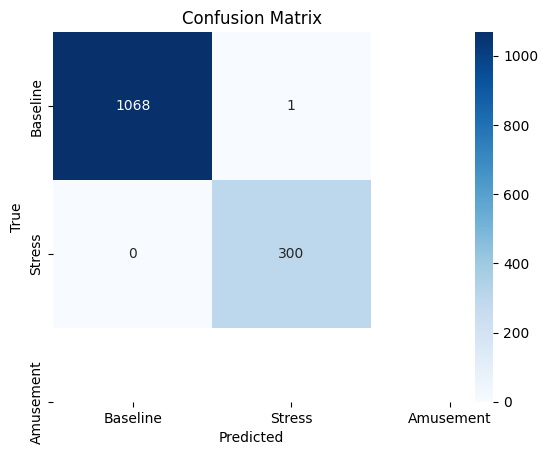

In [102]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define dims (example: 8 wrist + 9 chest)
wrist_dim, chest_dim = 6, 5
model = MultimodalWESADTransformer(wrist_dim=wrist_dim, chest_dim=chest_dim, embed_dim=64, num_classes=3)

# Train
model = train_model(model, train_loader, val_loader, device, epochs=20, lr=1e-3)

# Evaluate
evaluate_on_test(model, test_loader, device)

# **Multimodality Data**

In [103]:
from scipy.signal import resample  # This is the correct import

def resample_signal(signal, target_len):
    return resample(signal, target_len, axis=0)


In [104]:
def pad_windows(X, target_length):
    pad_width = target_length - X.shape[1]
    return np.pad(X, ((0, 0), (0, pad_width), (0, 0)), mode='constant')

In [105]:
def load_multiscale_wesad_data(base_path='WESAD/', 
                                window_sizes=[128, 256, 512],
                                overlap=0.75,
                                subject_ids=None,
                                chest_sensors=['ACC', 'ECG', 'Resp'], 
                                wrist_sensors=['ACC', 'EDA', 'TEMP', 'BVP'],
                                normalize=True):
    if subject_ids is None:
        subject_ids = [i for i in range(2, 18) if i != 12]

    X_all_scales, y_all_scales = [], []

    for window_size in window_sizes:
        print(f"\n🔍 Processing window size: {window_size}")
        X_scale, y_scale = load_all_wesad_data(
            base_path=base_path,
            subject_ids=subject_ids,
            chest_sensors=chest_sensors,
            wrist_sensors=wrist_sensors,
            window_size=window_size,
            overlap=overlap,
            normalize=normalize,
            return_modalities=False
        )
        X_all_scales.append(X_scale)
        y_all_scales.append(y_scale)

 
    max_len = max(x.shape[1] for x in X_all_scales)
    X_all_scales = [pad_windows(x, max_len) for x in X_all_scales]
    X_final = np.concatenate(X_all_scales)
    y_final = np.concatenate(y_all_scales)
    print(f"\n✅ Total samples after multi-scale windowing: {len(X_final)}")
    return X_final, y_final


In [106]:
X, y = load_multiscale_wesad_data(
    window_sizes=[128, 256, 512],
    overlap=0.875  # or 0.875 for more data
)



🔍 Processing window size: 128
Loading subject S2
Generated 1512 windows (window size: 128, step: 16)
Loading subject S3
Generated 1616 windows (window size: 128, step: 16)
Loading subject S4
Generated 1598 windows (window size: 128, step: 16)
Loading subject S5
Generated 1557 windows (window size: 128, step: 16)
Loading subject S6
Generated 1760 windows (window size: 128, step: 16)
Loading subject S7
Generated 1302 windows (window size: 128, step: 16)
Loading subject S8
Generated 1359 windows (window size: 128, step: 16)
Loading subject S9
Generated 1298 windows (window size: 128, step: 16)
Loading subject S10
Generated 1367 windows (window size: 128, step: 16)
Loading subject S11
Generated 1301 windows (window size: 128, step: 16)
Loading subject S13
Generated 1377 windows (window size: 128, step: 16)
Loading subject S14
Generated 1380 windows (window size: 128, step: 16)
Loading subject S15
Generated 1306 windows (window size: 128, step: 16)
Loading subject S16
Generated 1400 window

In [107]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import numpy as np
import pandas as pd

def balance_dataset(X, y, upsample_ratio=1.0, random_state=42):
    """
    Upsamples the minority class to balance the dataset.
    """
    X_0, X_1 = X[y == 0], X[y == 1]
    y_0, y_1 = y[y == 0], y[y == 1]

    n_1_target = int(len(y_0) * upsample_ratio)
    X_1_up, y_1_up = resample(X_1, y_1, replace=True, n_samples=n_1_target, random_state=random_state)

    X_bal = np.concatenate([X_0, X_1_up])
    y_bal = np.concatenate([y_0, y_1_up])
    
    indices = np.random.permutation(len(X_bal))
    return X_bal[indices], y_bal[indices]

def split_dataset(X, y, test_size=0.2, val_size=0.25, random_state=42):
    """
    Splits dataset into train/val/test sets with stratification.
    """
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size, stratify=y_temp, random_state=random_state)

    summary = pd.DataFrame({
        'Split': ['Train', 'Validation', 'Test'],
        'Total': [len(y_train), len(y_val), len(y_test)],
        'Class 0': [np.sum(y_train == 0), np.sum(y_val == 0), np.sum(y_test == 0)],
        'Class 1': [np.sum(y_train == 1), np.sum(y_val == 1), np.sum(y_test == 1)],
    })

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), summary



In [108]:


# Step 2: Balance the dataset
X_bal, y_bal = balance_dataset(X, y, upsample_ratio=1.0)
np.savez_compressed("wesad_balanced_multiwindow.npz", X=X_bal, y=y_bal)
# Step 3: Split into train/val/test
(train_X, train_y), (val_X, val_y), (test_X, test_y), split_summary = split_dataset(X_bal, y_bal)

# Step 4: View split statistics
print(split_summary)


        Split  Total  Class 0  Class 1
0       Train  44712    22356    22356
1  Validation  14904     7452     7452
2        Test  14904     7452     7452


In [109]:
import torch
from torch.utils.data import Dataset, DataLoader

class WESADDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [110]:
def create_dataloaders(train_data, val_data, test_data, batch_size=64, num_workers=0):
    train_X, train_y = train_data
    val_X, val_y = val_data
    test_X, test_y = test_data

    train_loader = DataLoader(WESADDataset(train_X, train_y), batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(WESADDataset(val_X, val_y), batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader = DataLoader(WESADDataset(test_X, test_y), batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return train_loader, val_loader, test_loader


In [111]:
train_loader, val_loader, test_loader = create_dataloaders(
    (train_X, train_y), (val_X, val_y), (test_X, test_y), batch_size=64
)

# Sample usage
for batch_X, batch_y in train_loader:
    print(batch_X.shape, batch_y.shape)
    break

torch.Size([64, 512, 11]) torch.Size([64])


In [112]:
combo_model = MultimodalWESADTransformer(wrist_dim=6, chest_dim=5, embed_dim=64, num_classes=3)

# Sample input: batch of 32, sequence length 128, feature_dim 17 (8+9)
sample_input = torch.randn(32, 128, 11)
output = combo_model(sample_input)  # [32, 3]

cuda
Epoch 01 | Train Loss: 0.1154 | Acc: 0.9570 | Val Loss: 0.0387 | Acc: 0.9889
Epoch 02 | Train Loss: 0.0285 | Acc: 0.9924 | Val Loss: 0.0414 | Acc: 0.9887
Epoch 03 | Train Loss: 0.0308 | Acc: 0.9919 | Val Loss: 0.0408 | Acc: 0.9917
Epoch 04 | Train Loss: 0.0199 | Acc: 0.9950 | Val Loss: 0.0101 | Acc: 0.9972
Epoch 05 | Train Loss: 0.0159 | Acc: 0.9958 | Val Loss: 0.0046 | Acc: 0.9981
Epoch 06 | Train Loss: 0.0144 | Acc: 0.9963 | Val Loss: 0.0244 | Acc: 0.9951
Epoch 07 | Train Loss: 0.0134 | Acc: 0.9966 | Val Loss: 0.0041 | Acc: 0.9989
Epoch 08 | Train Loss: 0.0074 | Acc: 0.9981 | Val Loss: 0.0125 | Acc: 0.9969
Epoch 09 | Train Loss: 0.0159 | Acc: 0.9956 | Val Loss: 0.0046 | Acc: 0.9985
Epoch 10 | Train Loss: 0.0098 | Acc: 0.9977 | Val Loss: 0.0046 | Acc: 0.9987
Epoch 11 | Train Loss: 0.0071 | Acc: 0.9983 | Val Loss: 0.0152 | Acc: 0.9972
Epoch 12 | Train Loss: 0.0112 | Acc: 0.9973 | Val Loss: 0.0187 | Acc: 0.9955
Epoch 13 | Train Loss: 0.0064 | Acc: 0.9983 | Val Loss: 0.0022 | Acc: 0

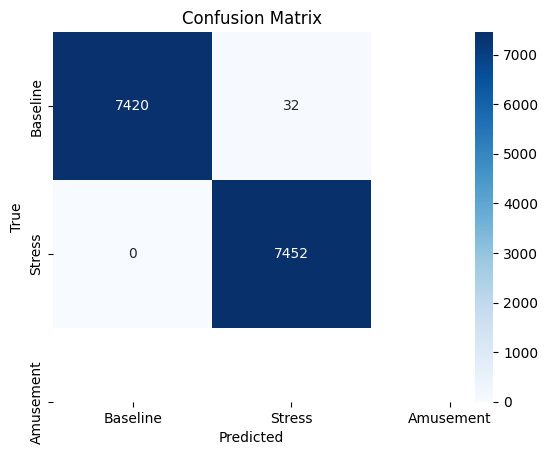

In [113]:
# Train
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
train_model = train_model(combo_model, train_loader, val_loader, device, epochs=20, lr=1e-3)

# Evaluate
evaluate_on_test(train_model, test_loader, device)

In [114]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [115]:
def plot_binary_roc(model, dataloader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            outputs = model(X)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # Get probability for class 1 (positive class)
            all_labels.append(y.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)

    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Binary ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

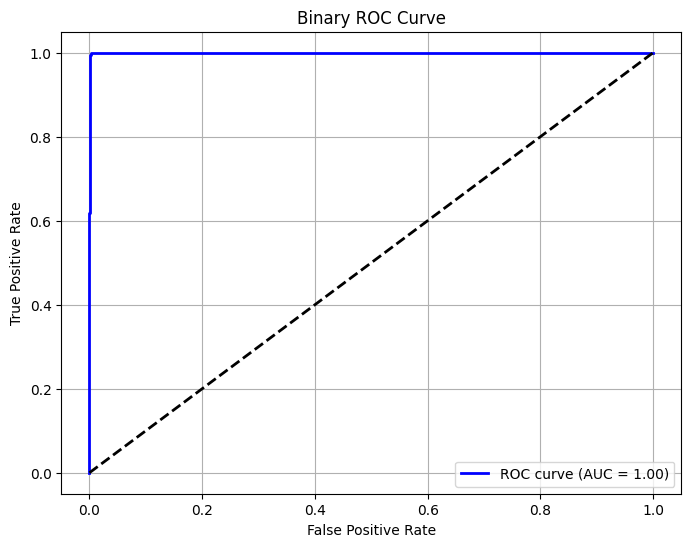

In [119]:
plot_binary_roc(train_model,test_loader, device)

In [120]:
import torch
from sklearn.metrics import classification_report

def evaluate_model(model, dataloader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in dataloader:
            inputs, labels = batch  # Assuming batch = (inputs, labels)
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)  # Forward pass
            preds = torch.argmax(outputs, dim=1)  # Take highest score class

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Generate classification report
    report = classification_report(
        y_true, 
        y_pred, 
        target_names=["Baseline", "Stress"],
        digits=4
    )
    print(report)
    return report


In [122]:
evaluate_model(train_model, test_loader, device)

              precision    recall  f1-score   support

    Baseline     1.0000    0.9957    0.9978      7452
      Stress     0.9957    1.0000    0.9979      7452

    accuracy                         0.9979     14904
   macro avg     0.9979    0.9979    0.9979     14904
weighted avg     0.9979    0.9979    0.9979     14904



'              precision    recall  f1-score   support\n\n    Baseline     1.0000    0.9957    0.9978      7452\n      Stress     0.9957    1.0000    0.9979      7452\n\n    accuracy                         0.9979     14904\n   macro avg     0.9979    0.9979    0.9979     14904\nweighted avg     0.9979    0.9979    0.9979     14904\n'